In [97]:
import numpy as np
import matplotlib.pyplot as plt

In [98]:
def mutate_function(
        pop,                # Population
        k,                  # Idx of population to mutate
        F,                  # F params
        sorted_indices,     # Sorted population indices by fitness
        p=0.1               # Percetage of population to chosen
):
    n = len(pop)

    p_best_range = max(1, int(p * n))
    p_best_idx = np.random.choice(sorted_indices[:p_best_range])

    candidates_to_select = [i for i in range(n) if i != k]
    r1, r2 = np.random.choice(candidates_to_select, 2, replace=False)

    v_k = pop[k] + F * (pop[p_best_idx] - pop[k]) + F * (pop[r1] - pop[r2])
    return v_k

In [99]:
def target_function(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1.0 - x[:-1])**2.0)

def differential_evolution_basic(
        n_vars,
        target_function,
        mutation_function,
        max_gens=500,
        pop_size=100,
        H=10,               # Length of memory for F and CR
        lb=-5.0,
        ub=5.0,
):
    # Init
    pop = lb + np.random.rand(pop_size, n_vars) * (ub - lb)
    fitness = [target_function(ind) for ind in pop]

    # Memory for F and CR (init = 0.5 for all)
    m_f = np.ones(H) * 0.5
    m_cr = np.ones(H) * 0.5
    m_count = 0

    fitness_history = []

    for gen in range(max_gens):
        success_f = []
        success_cr = []
        fitness_diff = []

        sorted_indices = np.argsort(fitness)
        new_pop = np.copy(pop)

        for i in range(pop_size):

            # Create new F and CR
            r = np.random.randint(0, H)

            f_i = np.random.standard_cauchy() * 0.1 + m_f[r]
            while f_i <= 0:
                f_i = np.random.standard_cauchy() * 1 + m_f[r]
            f_i = min(f_i, 1.0)

            cr_i = np.random.normal(m_cr[r], 0.1)
            cr_i = np.clip(cr_i, 0.0, 1.0)

            # Mutation
            v_i = mutation_function(pop, i, f_i, sorted_indices, 0.1)

            # Cross over
            j_rand = np.random.randint(0, n_vars)
            mask = np.random.rand(n_vars) < cr_i
            mask[j_rand] = True
            o_i = np.where(mask, v_i, pop[i])

            # Selection
            fitness_new = target_function(o_i)
            if fitness_new < fitness[i]:
                if fitness_new < fitness[i]:
                    success_f.append(f_i)
                    success_cr.append(cr_i)
                    fitness_diff.append(fitness[i] - fitness_new)
                new_pop[i] = o_i
                fitness[i] = fitness_new

        if len(success_f) > 0:
            weights = np.array(fitness_diff) / np.sum(fitness_diff)

            m_cr[m_count] = np.sum(weights * np.array(success_cr))

            num = np.sum(weights * (np.array(success_f) ** 2))
            den = np.sum(weights * np.array(success_f))
            m_f[m_count] = num / den if den != 0 else m_f[m_count]

            m_count = (m_count + 1) % H

        pop = new_pop
        fitness_history.append(np.min(fitness))

        if gen % 20 == 0:
            print(f"Generation {gen} - Best fitness: {np.max(fitness)}")

    best_idx = np.argmin(fitness)
    return pop[best_idx], fitness[best_idx], fitness_history

Generation 0 - Best fitness: 287235.6595845948
Generation 20 - Best fitness: 3230.6104638210027
Generation 40 - Best fitness: 106.96429858692872
Generation 60 - Best fitness: 16.35006124012895
Generation 80 - Best fitness: 9.51189362795899
Generation 100 - Best fitness: 7.510107568099744
Generation 120 - Best fitness: 6.462246626367121
Generation 140 - Best fitness: 5.392137101927213
Generation 160 - Best fitness: 4.221211413757307
Generation 180 - Best fitness: 2.9513634294518503
Generation 200 - Best fitness: 1.6227462892789033
Generation 220 - Best fitness: 0.7104174405262789
Generation 240 - Best fitness: 0.23459701452145387
Generation 260 - Best fitness: 0.0668098891548973
Generation 280 - Best fitness: 0.00634107460759762
Generation 300 - Best fitness: 0.0007668996854255355
Generation 320 - Best fitness: 8.260674196261816e-05
Generation 340 - Best fitness: 4.108633940983653e-06
Generation 360 - Best fitness: 9.169768592925332e-08
Generation 380 - Best fitness: 1.8426169350162228e

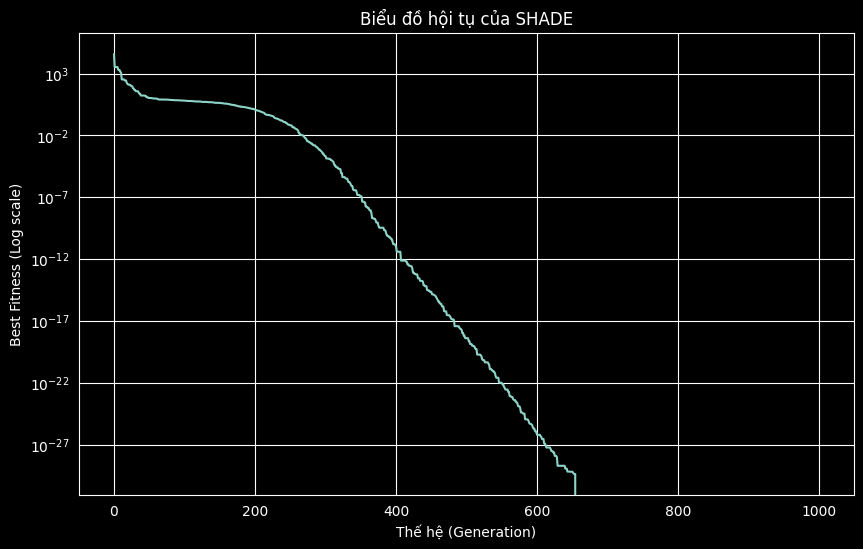

In [100]:
best_p, best_f, fitness_history = differential_evolution_basic(
    n_vars=10,
    target_function=target_function,
    mutation_function=mutate_function,
    max_gens=1000,
    pop_size=50,
    H=15,
)
print(f"Best mean: {best_p} | Best fitness: {best_f}")

plt.figure(figsize=(10, 6))
plt.plot(fitness_history)
# plt.plot(np.array(fitness_history) + 1e-20)
plt.yscale('log')
plt.title('Biểu đồ hội tụ của SHADE')
plt.xlabel('Thế hệ (Generation)')
plt.ylabel('Best Fitness (Log scale)')
plt.grid(True, which="both", ls="-")
plt.show()